In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/raw/dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Shape:", df.shape)

print("\n")

df.info()

print("\nMissing Values\n")

print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (1000, 9)


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB

Missing Values

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicates: 0


In [ ]:
df.info()
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

# Create Month column
df["Month"] = df["Date"].dt.to_period("M").astype(str)

# Check final shape
print(df.shape)

(1000, 10)


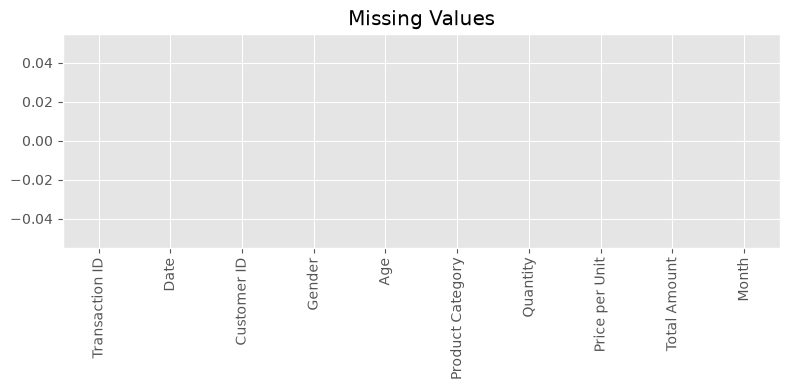

In [7]:
plt.figure(figsize=(8,4))

df.isnull().sum().plot(kind="bar")

plt.title("Missing Values")

plt.tight_layout()

plt.savefig("../reports/figures/missing_values.png", dpi=200)

plt.show()

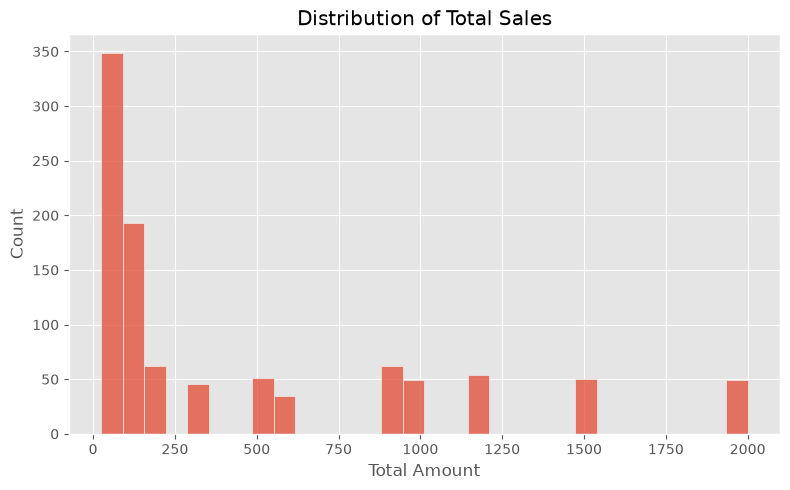

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total Amount"], bins=30)

plt.title("Distribution of Total Sales")

plt.tight_layout()

plt.savefig("../reports/figures/sales_distribution.png", dpi=200)

plt.show()

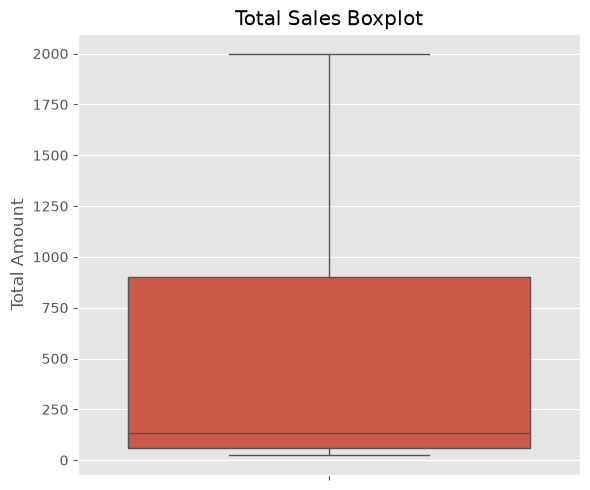

In [9]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["Total Amount"])

plt.title("Total Sales Boxplot")

plt.tight_layout()

plt.savefig("../reports/figures/outliers_boxplot.png", dpi=200)

plt.show()

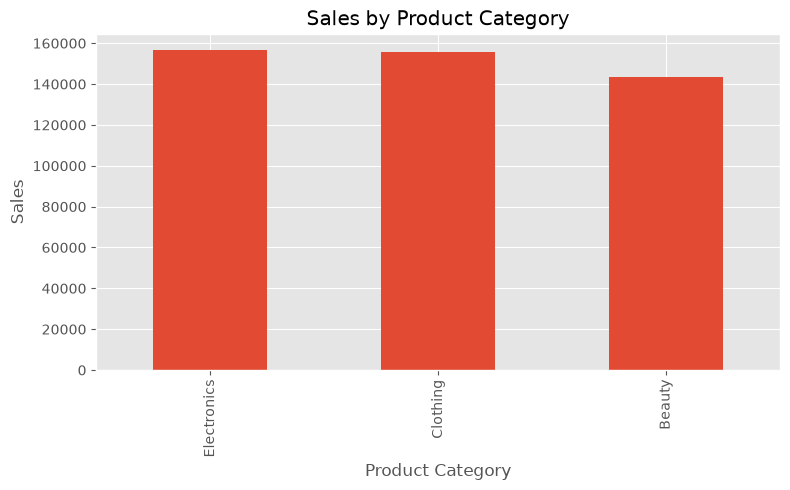

In [10]:
plt.figure(figsize=(8,5))

sales = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

sales.plot(kind="bar")

plt.ylabel("Sales")

plt.title("Sales by Product Category")

plt.tight_layout()

plt.savefig("../reports/figures/top_categories.png", dpi=200)

plt.show()

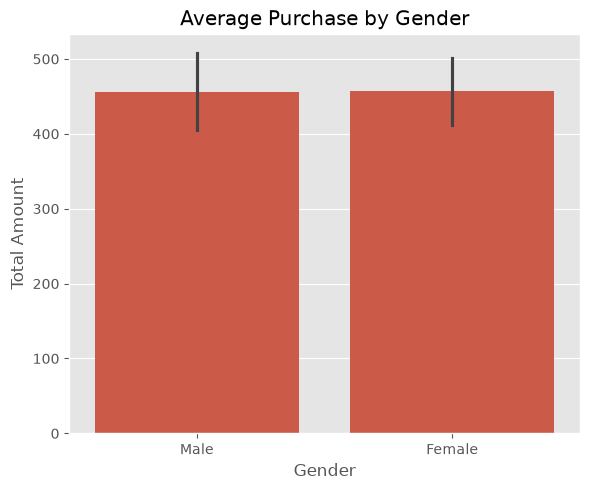

In [11]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="Gender",
    y="Total Amount",
    estimator="mean"
)

plt.title("Average Purchase by Gender")

plt.tight_layout()

plt.savefig("../reports/figures/gender_comparison.png", dpi=200)

plt.show()

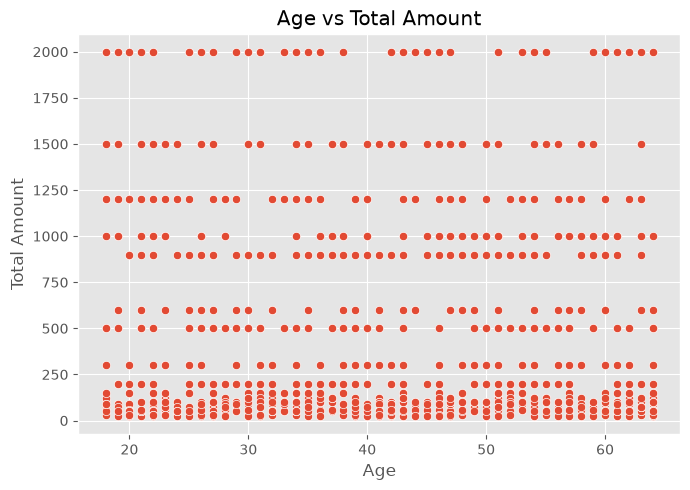

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total Amount"
)

plt.title("Age vs Total Amount")

plt.tight_layout()

plt.savefig("../reports/figures/scatter_age_sales.png", dpi=200)

plt.show()

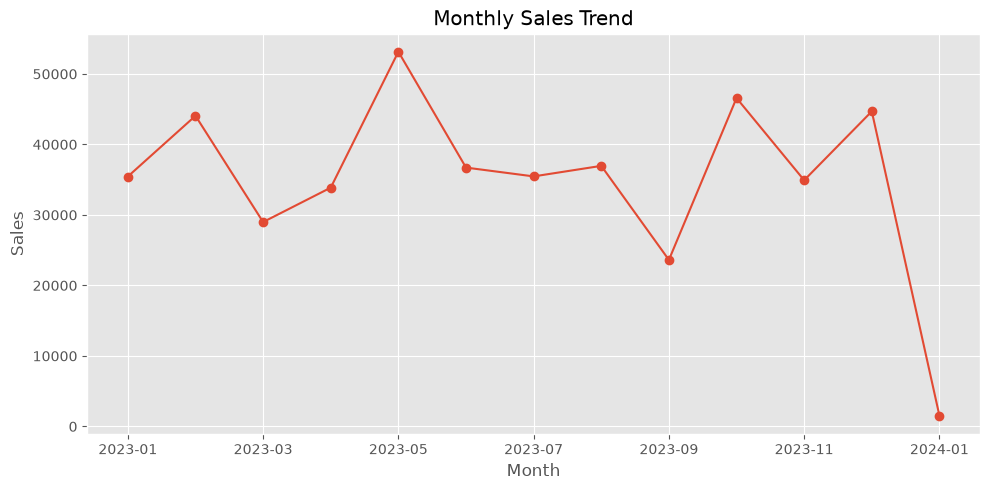

In [13]:
monthly = (
    df.groupby("Month")["Total Amount"]
      .sum()
)

plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.ylabel("Sales")

plt.title("Monthly Sales Trend")

plt.tight_layout()

plt.savefig("../reports/figures/trend_over_time.png", dpi=200)

plt.show()

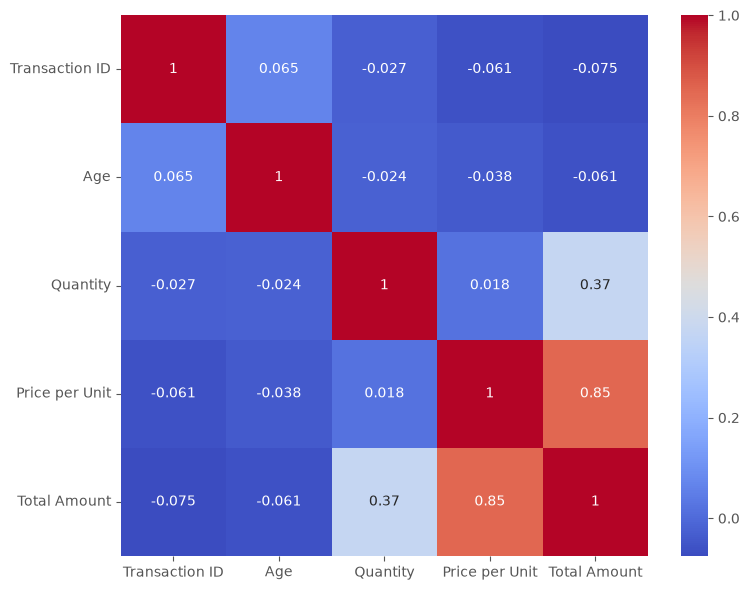

In [14]:
plt.figure(figsize=(8,6))

numeric = df.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.tight_layout()

plt.savefig("../reports/figures/correlation_heatmap.png", dpi=200)

plt.show()

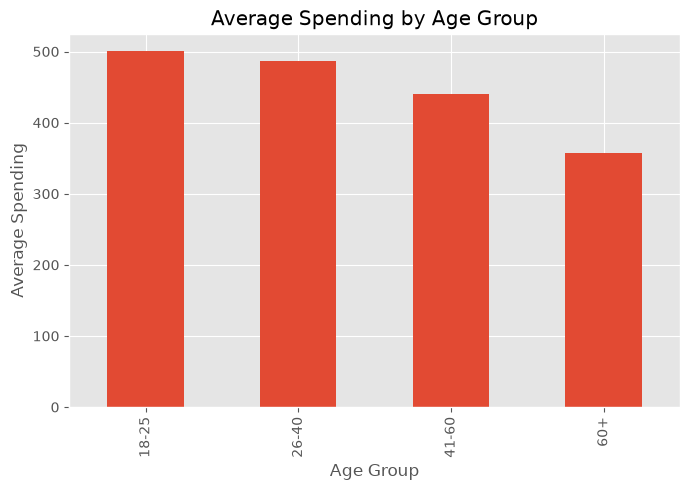

In [15]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0,25,40,60,100],
    labels=["18-25","26-40","41-60","60+"]
)

segment = (
    df.groupby("Age Group")["Total Amount"]
      .mean()
)

plt.figure(figsize=(7,5))

segment.plot(kind="bar")

plt.ylabel("Average Spending")

plt.title("Average Spending by Age Group")

plt.tight_layout()

plt.savefig("../reports/figures/segment_comparison.png", dpi=200)

plt.show()

# Executive Summary

## Key Insights

- Total sales vary considerably across product categories.
- Some age groups spend more on average than others.
- Monthly sales show seasonal fluctuations.
- Male and female customers have comparable purchasing behavior with slight differences in average spending.
- A small number of high-value transactions contribute disproportionately to revenue.

## Recommendations

1. Focus promotions on the highest-performing product categories.
2. Create targeted campaigns for the highest-spending age groups.
3. Investigate seasonal sales trends to optimize inventory.
4. Monitor large transactions separately for premium customer opportunities.